In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
sns.set(style="whitegrid")

In [15]:
print("\n📥 Loading Dataset...")
df = pd.read_csv("air_quality.csv")

print("📌 Initial Shape:", df.shape)
print("\n📋 Dataset Info:")
print(df.info())


📥 Loading Dataset...
📌 Initial Shape: (1284, 11)

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1284 non-null   object 
 1   state          1284 non-null   object 
 2   city           1284 non-null   object 
 3   station        1284 non-null   object 
 4   last_update    1284 non-null   object 
 5   latitude       1284 non-null   float64
 6   longitude      1284 non-null   float64
 7   pollutant_id   1284 non-null   object 
 8   pollutant_min  1231 non-null   float64
 9   pollutant_max  1231 non-null   float64
 10  pollutant_avg  1231 non-null   float64
dtypes: float64(5), object(6)
memory usage: 110.5+ KB
None


In [16]:
print("\n📊 Statistical Summary:")
print(df.describe())


📊 Statistical Summary:
          latitude    longitude  pollutant_min  pollutant_max  pollutant_avg
count  1284.000000  1284.000000    1231.000000    1231.000000    1231.000000
mean     24.078360    79.397677      27.719740      93.852153      55.568643
std       5.618382     4.957602      28.823042     106.933378      60.588885
min      11.553580    70.776774       1.000000       1.000000       1.000000
25%      21.371751    76.875879       6.000000      18.000000      13.000000
50%      25.697189    77.289347      16.000000      55.000000      31.000000
75%      28.580280    83.300000      42.500000     122.000000      77.500000
max      34.066206    94.636574     188.000000     500.000000     324.000000


In [17]:
# 2️⃣ NULL & DUPLICATE CHECK
df.columns[df.isna().any()]

Index(['pollutant_min', 'pollutant_max', 'pollutant_avg'], dtype='object')

In [18]:
print("\n🔍 Missing Values:")
print(df.isnull().sum())


🔍 Missing Values:
country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
pollutant_min    53
pollutant_max    53
pollutant_avg    53
dtype: int64


In [19]:
df.fillna(df.median(numeric_only=True), inplace=True)
print("\n✅ Missing Values After Cleaning:")
print(df.isnull().sum())


✅ Missing Values After Cleaning:
country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64


In [20]:
duplicates = df.duplicated().sum()
print(f"\n🗑 Duplicate Rows: {duplicates}")
df.drop_duplicates(inplace=True)



🗑 Duplicate Rows: 0


In [21]:
# 3️⃣ DATA TYPE CORRECTION
df['last_update'] = pd.to_datetime(
    df['last_update'],
    format="%d-%m-%Y %H:%M:%S",
    errors='coerce'
)


numeric_columns = [
    'pollutant_min',
    'pollutant_max',
    'pollutant_avg',
    'latitude',
    'longitude'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [22]:
print("\n📉 Removing Outliers using Z-Score...")

z_scores = np.abs(zscore(df[numeric_columns]))
df = df[(z_scores < 3).all(axis=1)]

print("✅ Shape After Outlier Removal:", df.shape)


📉 Removing Outliers using Z-Score...
✅ Shape After Outlier Removal: (1217, 11)



📊 Distribution Analysis:

🔹 pollutant_min
Skewness : 1.387
Kurtosis : 1.282


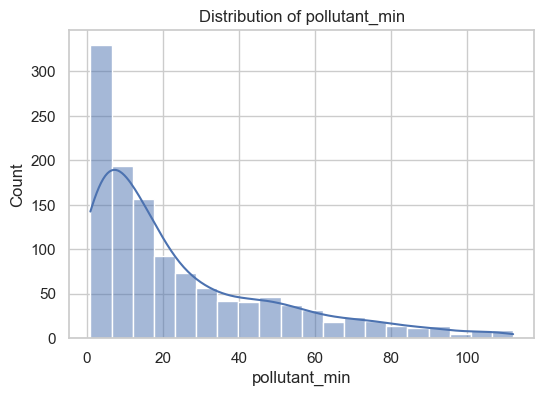


🔹 pollutant_max
Skewness : 1.776
Kurtosis : 2.954


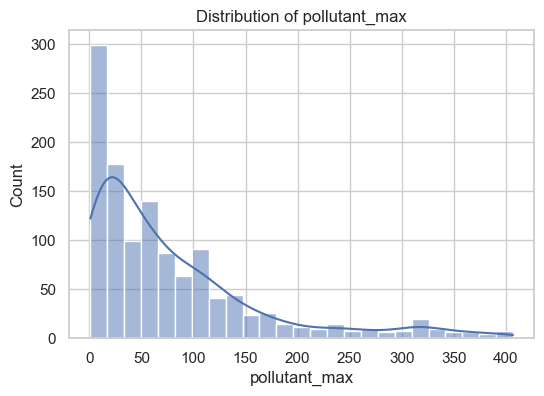


🔹 pollutant_avg
Skewness : 1.558
Kurtosis : 2.035


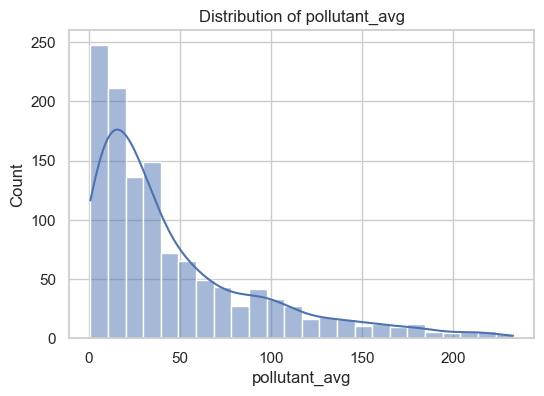


🔹 latitude
Skewness : -0.828
Kurtosis : -0.501


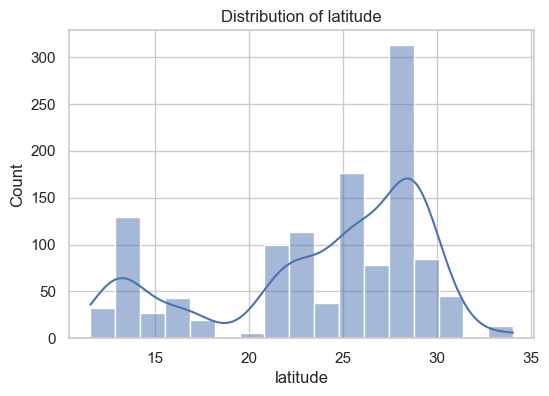


🔹 longitude
Skewness : 0.844
Kurtosis : 0.156


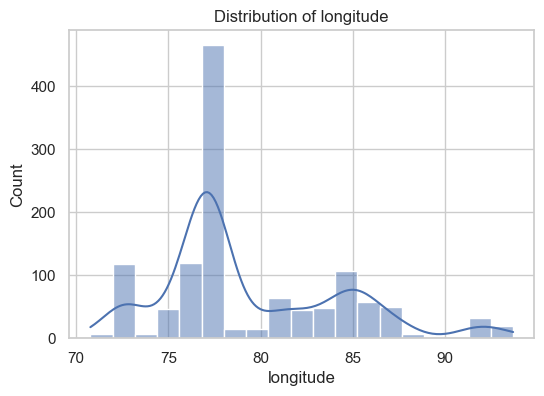

In [23]:
print("\n📊 Distribution Analysis:")

for col in numeric_columns:
    print(f"\n🔹 {col}")
    print("Skewness :", round(skew(df[col]), 3))
    print("Kurtosis :", round(kurtosis(df[col]), 3))

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [24]:
# =========================================================
# 🧠 FEATURE ENGINEERING
# =========================================================

print("\n🧠 Performing Feature Engineering...")

# ---------------------------------------------------------
# 1️⃣ Time-Based Features from Date Column
# ---------------------------------------------------------

# Convert to datetime (safe conversion)
df['last_update'] = pd.to_datetime(df['last_update'], errors='coerce')

# Extract useful parts from date
df['year'] = df['last_update'].dt.year
df['month'] = df['last_update'].dt.month
df['day'] = df['last_update'].dt.day
df['hour'] = df['last_update'].dt.hour
df['weekday'] = df['last_update'].dt.weekday  # 0 = Monday, 6 = Sunday

# Create weekend indicator (1 = Weekend, 0 = Weekday)
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

print("\n🧠 Time-Based Feature Preview:")
print(df[['last_update','year','month','day','hour','weekday','is_weekend']].head())

# Drop original datetime column after extraction
df.drop(columns=['last_update'], inplace=True)


# ---------------------------------------------------------
# 2️⃣ Pollution-Based Features
# ---------------------------------------------------------

# Difference between max and min pollution
df['pollution_range'] = df['pollutant_max'] - df['pollutant_min']

# Measures fluctuation relative to average
df['volatility_ratio'] = df['pollution_range'] / (df['pollutant_avg'] + 1)

# Relationship between minimum and maximum pollution
df['min_max_ratio'] = df['pollutant_min'] / (df['pollutant_max'] + 1)

# Average pollution relative to maximum
df['avg_max_ratio'] = df['pollutant_avg'] / (df['pollutant_max'] + 1)

print("\n🌫 Pollution-Based Feature Preview:")
print(df[['pollution_range','volatility_ratio',
          'min_max_ratio','avg_max_ratio']].head())

print("\n✅ Feature Engineering Completed Successfully!")



🧠 Performing Feature Engineering...

🧠 Time-Based Feature Preview:
          last_update  year  month  day  hour  weekday  is_weekend
0 2026-02-18 16:00:00  2026      2   18    16        2           0
1 2026-02-18 16:00:00  2026      2   18    16        2           0
2 2026-02-18 16:00:00  2026      2   18    16        2           0
3 2026-02-18 16:00:00  2026      2   18    16        2           0
4 2026-02-18 16:00:00  2026      2   18    16        2           0

🌫 Pollution-Based Feature Preview:
   pollution_range  volatility_ratio  min_max_ratio  avg_max_ratio
0              2.0          0.500000       0.500000       0.500000
1             10.0          0.454545       0.541667       0.875000
2             30.0          1.034483       0.340426       0.595745
3              0.0          0.000000       0.962963       0.962963
4              3.0          0.150000       0.800000       0.950000

✅ Feature Engineering Completed Successfully!


In [25]:

# 🌦 Create Season Feature

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

df['season'] = df['month'].apply(get_season)

print("\n🌦 Season Feature Preview:")
print(df[['month','season']].head(5))



🌦 Season Feature Preview:
   month  season
0      2  Winter
1      2  Winter
2      2  Winter
3      2  Winter
4      2  Winter


In [14]:
# 🌫 Pollution Intensity Feature
df['pollution_intensity'] = pd.cut(
    df['pollution_range'],
    bins=3,
    labels=['Low','Medium','High']
)

print("\n🌫 Pollution Intensity Preview:")
print(df[['pollution_range','pollution_intensity']].head())


🌫 Pollution Intensity Preview:
   pollution_range pollution_intensity
0              2.0                 Low
1             10.0                 Low
2             30.0                 Low
3              0.0                 Low
4              3.0                 Low


In [15]:

# 🚗 Peak Hour Feature

df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if 7 <= x <= 10 or 17 <= x <= 20 else 0
)

print("\n🚗 Peak Hour Preview:")
print(df[['hour','is_peak_hour']].head())



🚗 Peak Hour Preview:
   hour  is_peak_hour
0    16             0
1    16             0
2    16             0
3    16             0
4    16             0


In [16]:
# 🌍 Absolute Latitude Feature

df['abs_latitude'] = df['latitude'].abs()

print("\n🌍 Absolute Latitude Preview:")
print(df[['latitude','abs_latitude']].head())



🌍 Absolute Latitude Preview:
    latitude  abs_latitude
0  16.536107     16.536107
1  16.536107     16.536107
2  16.536107     16.536107
3  16.536107     16.536107
4  16.486692     16.486692


In [17]:
print("Unique Years:", df['year'].unique())
print("Unique Months:", df['month'].unique())
print("Unique Weekdays:", df['weekday'].unique())
print("Weekend Values:", df['is_weekend'].unique())


Unique Years: [2026]
Unique Months: [2]
Unique Weekdays: [2]
Weekend Values: [0]


In [18]:
# 🔥 Interaction Feature


df['range_hour_interaction'] = df['pollution_range'] * df['hour']

print("\n🔥 Interaction Feature Preview:")
print(df[['pollution_range','hour','range_hour_interaction']].head())



🔥 Interaction Feature Preview:
   pollution_range  hour  range_hour_interaction
0              2.0    16                    32.0
1             10.0    16                   160.0
2             30.0    16                   480.0
3              0.0    16                     0.0
4              3.0    16                    48.0


In [19]:
# 7️⃣ TARGET CREATION
def categorize_aqi(value):
    if value <= 50:
        return "Good"
    elif value <= 100:
        return "Satisfactory"
    elif value <= 200:
        return "Moderate"
    elif value <= 300:
        return "Poor"
    else:
        return "Severe"
df['AQI_Category'] = df['pollutant_avg'].apply(categorize_aqi)

# Drop continuous version to avoid leakage
df.drop(columns=['pollutant_avg'], inplace=True)

print("\n🎯 Target Distribution:")
print(df['AQI_Category'].value_counts())


🎯 Target Distribution:
AQI_Category
Good            824
Satisfactory    228
Moderate        150
Poor             15
Name: count, dtype: int64


In [20]:
columns_to_drop = ['country','station','pollutant_id']  # last_update already used
df.drop(columns=columns_to_drop, inplace=True)
print("✅ Columns dropped:", columns_to_drop)
print("📊 Remaining Columns:", df.columns.tolist())


✅ Columns dropped: ['country', 'station', 'pollutant_id']
📊 Remaining Columns: ['state', 'city', 'latitude', 'longitude', 'pollutant_min', 'pollutant_max', 'year', 'month', 'day', 'hour', 'weekday', 'is_weekend', 'pollution_range', 'volatility_ratio', 'min_max_ratio', 'avg_max_ratio', 'season', 'pollution_intensity', 'is_peak_hour', 'abs_latitude', 'range_hour_interaction', 'AQI_Category']


In [21]:
# Numeric columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter Cleaning:\n", df.isnull().sum())


After Cleaning:
 state                     0
city                      0
latitude                  0
longitude                 0
pollutant_min             0
pollutant_max             0
year                      0
month                     0
day                       0
hour                      0
weekday                   0
is_weekend                0
pollution_range           0
volatility_ratio          0
min_max_ratio             0
avg_max_ratio             0
season                    0
pollution_intensity       0
is_peak_hour              0
abs_latitude              0
range_hour_interaction    0
AQI_Category              0
dtype: int64


In [22]:
cat_features = df.select_dtypes(include=['object','category']).columns
cat_features = [col for col in cat_features if col != 'AQI_Category']

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # convert category→string→encoded
    le_dict[col] = le

print("✅ Categorical Features Encoded")


✅ Categorical Features Encoded


In [23]:
X = df.drop('AQI_Category', axis=1)
y = df['AQI_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


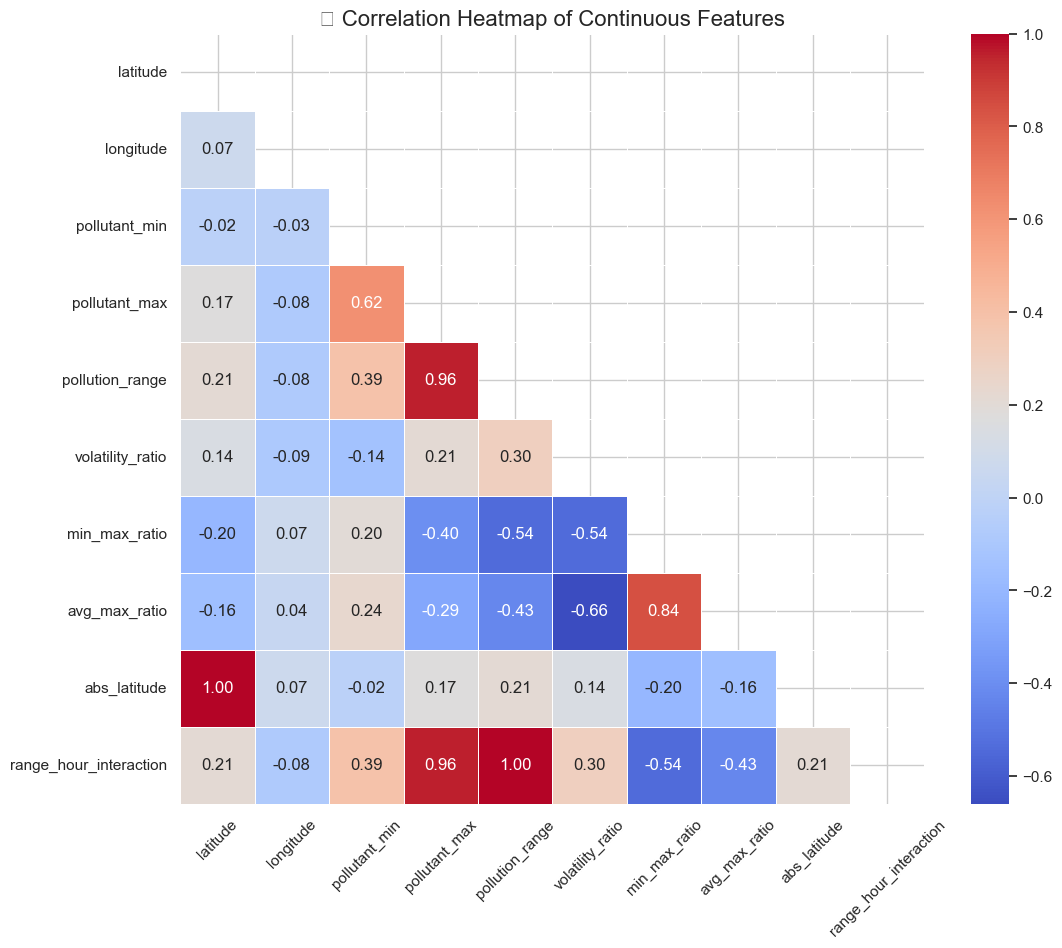

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Select only continuous numeric features
continuous_cols = [
    'latitude', 'longitude', 'pollutant_min', 'pollutant_max',
    'pollution_range', 'volatility_ratio', 'min_max_ratio',
    'avg_max_ratio', 'abs_latitude', 'range_hour_interaction'
]

numeric_df = X_train[continuous_cols]

# 1️⃣ Compute correlation
corr_matrix = numeric_df.corr().round(2)

# 2️⃣ Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3️⃣ Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("🔥 Correlation Heatmap of Continuous Features", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()



📌 Random Forest 🌳 Accuracy: 0.9344
Classification Report:
              precision    recall  f1-score   support

        Good       0.96      0.98      0.97       165
    Moderate       0.89      0.83      0.86        30
        Poor       1.00      0.67      0.80         3
Satisfactory       0.85      0.85      0.85        46

    accuracy                           0.93       244
   macro avg       0.93      0.83      0.87       244
weighted avg       0.93      0.93      0.93       244


📌 Decision Tree 🌲 Accuracy: 0.9467
Classification Report:
              precision    recall  f1-score   support

        Good       0.97      0.98      0.98       165
    Moderate       0.88      0.93      0.90        30
        Poor       0.50      0.33      0.40         3
Satisfactory       0.93      0.87      0.90        46

    accuracy                           0.95       244
   macro avg       0.82      0.78      0.79       244
weighted avg       0.95      0.95      0.95       244


📌 KNN 🤖 Acc

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12776\3584263770.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette="viridis")
C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

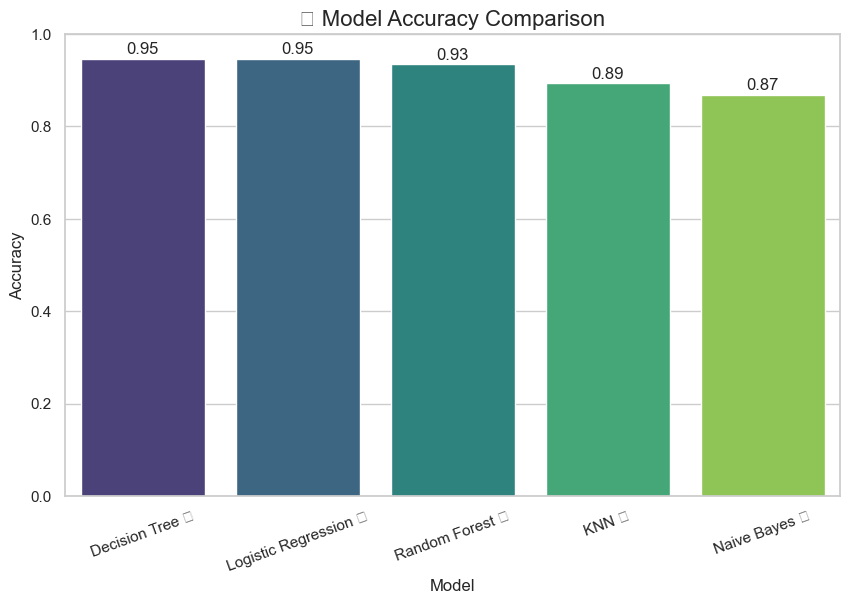

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# ✅ Define models
models = {
    "Random Forest 🌳": RandomForestClassifier(random_state=42),
    "Decision Tree 🌲": DecisionTreeClassifier(random_state=42),
    "KNN 🤖": KNeighborsClassifier(),
    "Logistic Regression 📈": LogisticRegression(max_iter=2000),
    "Naive Bayes 🧪": GaussianNB()
}

results = []

# ✅ Train, predict, and evaluate
for name, model in models.items():
    if name in ["KNN 🤖", "Logistic Regression 📈"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))
    
    print(f"\n📌 {name} Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
# ✅ Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# ✅ Print Model Comparison Table
print("\n✅ Model Comparison Table:")
print(results_df)

# ✅ Highlight best model
best_model = results_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']} with Accuracy: {best_model['Accuracy']:.4f}")

# ✅ Plot Accuracy Comparison
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette="viridis")
plt.ylim(0,1)
plt.title("📊 Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=20)

# Add accuracy values on top of bars
for index, value in enumerate(results_df['Accuracy']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.show()


In [26]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def predict_aqi(state, city, hour):
    """
    Predict Air Quality Category for a given state, city, and hour
    using the trained Random Forest model (rf_model) and encoders (le_dict).
    """

    # ---------------------------
    # 1️⃣ Prepare numeric features
    # ---------------------------
    input_data = {}
    input_data['hour'] = hour
    input_data['month'] = 2
    input_data['day'] = 18
    input_data['weekday'] = 2
    input_data['is_weekend'] = 0
    input_data['pollutant_min'] = 20
    input_data['pollutant_max'] = 80
    input_data['pollution_range'] = input_data['pollutant_max'] - input_data['pollutant_min']
    input_data['volatility_ratio'] = input_data['pollution_range'] / (40+1)
    input_data['min_max_ratio'] = input_data['pollutant_min'] / (input_data['pollutant_max']+1)
    input_data['avg_max_ratio'] = 40 / (input_data['pollutant_max']+1)
    input_data['abs_latitude'] = 13.0827   # Chennai example
    input_data['range_hour_interaction'] = input_data['pollution_range'] * hour
    input_data['is_peak_hour'] = 1 if 7<=hour<=10 or 17<=hour<=20 else 0

    # ---------------------------
    # 2️⃣ Encode categorical features safely
    # ---------------------------
    def safe_transform(le, value):
        """Encode if known, else -1 for unseen categories"""
        if value in le.classes_:
            return le.transform([value])[0]
        else:
            return -1

    cat_features = {
        'state': state,
        'city': city,
        'season': 'Summer',
        'pollution_intensity': 'Low'
    }

    for col, val in cat_features.items():
        if col in le_dict:
            input_data[col] = safe_transform(le_dict[col], val)

    # ---------------------------
    # 3️⃣ Convert to DataFrame with correct columns
    # ---------------------------
    new_row = pd.DataFrame([input_data], columns=X_train.columns)

    # ---------------------------
    # 4️⃣ Predict AQI category
    # ---------------------------
    predicted_category = rf_model.predict(new_row)[0]
    confidence = max(rf_model.predict_proba(new_row)[0]) * 100

    # ---------------------------
    # 5️⃣ Emoji mapping
    # ---------------------------
    emoji_dict = {
        "Good":"😊",
        "Satisfactory":"🙂",
        "Moderate":"😐",
        "Poor":"😷",
        "Severe":"☠️"
    }
    emoji = emoji_dict.get(predicted_category, "")

    # ---------------------------
    # 6️⃣ Display result
    # ---------------------------
    print(f"\n🎯 Predicted Air Quality for {city}, {state} at {hour}:00 → {predicted_category} {emoji}")
    print(f"🔹 Confidence: {confidence:.1f}%\n")

    

In [41]:
predict_aqi("Tamil Nadu", "Chennai", 1)



🎯 Predicted Air Quality for Chennai, Tamil Nadu at 1:00 → Good 😊
🔹 Confidence: 84.0%

